In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
torchvision.__version__

'0.25.0+cu128'

In [ ]:
torch.__version__

'2.10.0+cu128'

In [ ]:
!nvidia-smi

Fri Feb 20 07:33:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
torch.cuda.is_available()

True

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
print(f"Using Device: {device}")

Using Device: cuda


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

In [ ]:
3e-4

0.0003

In [ ]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

# IMAGE TRANSFORMATION

In [ ]:
from matplotlib.colors import Normalize
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

In [ ]:
from torchvision import datasets

train_dataset = datasets.CIFAR10(root="data",
                                 train=True,
                                 download=True,
                                 transform=transform_train)

In [ ]:
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [ ]:
from torchvision import datasets

test_dataset = datasets.CIFAR10(root="data",
                                train=False,
                                download=True,
                                transform=transform_test)
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [ ]:
len(train_dataset)

50000

In [ ]:
len(test_dataset)

10000

In [ ]:
BATCH_SIZE

128

In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

In [ ]:
print(f"DataLoader: {train_loader, test_loader}")
print(f"Length of train_loader: {len(train_loader)} batches of {BATCH_SIZE}...")
print(f"Length of test_loader: {len(test_loader)} batches of {BATCH_SIZE}...")

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x7bf4ca5e8410>, <torch.utils.data.dataloader.DataLoader object at 0x7bf4ca6eebd0>)
Length of train_loader: 391 batches of 128...
Length of test_loader: 79 batches of 128...


In [ ]:
128 * 390.625

50000.0

In [ ]:
50000 / 128

390.625

# ViT implmentation

In [ ]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
  def __init__(self,
               IMAGE_SIZE,
               PATCH_SIZE,
               in_channels,
               EMBED_DIM):
    super().__init__()
    self.PATCH_SIZE = PATCH_SIZE
    self.proj = nn.Conv2d(in_channels=in_channels,

                          out_channels=EMBED_DIM,
                          kernel_size=PATCH_SIZE,
                          stride=PATCH_SIZE)
    num_patches = (IMAGE_SIZE // PATCH_SIZE) ** 2
    self.cls_token = nn.Parameter(torch.randn(1, 1, EMBED_DIM))
    self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, EMBED_DIM))



  def forward(self, x: torch.Tensor):
    B = x.size(0)
    x = self.proj(x) # (B, E, H/P, W/P)
    x = x.flatten(2).transpose(1, 2) # (B, N , E)
    cls_token = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_token, x), dim=1)
    x = x + self.pos_embedding
    return x

In [ ]:
import torch.nn.functional as F

class MLP(nn.Module):
  def __init__(self,
               in_features,
               hidden_features,
               DROP_RATE):
    super().__init__()
    self.fc1 = nn.Linear(in_features=in_features,
                         out_features=hidden_features)
    self.fc2 = nn.Linear(in_features=hidden_features,
                         out_features=in_features)
    self.drop = nn.Dropout(DROP_RATE)

  def forward(self, x):
    x = self.drop(F.gelu(self.fc1(x)))
    x = self.drop(self.fc2(x))
    return x

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self, EMBED_DIM, NUM_HEADS, MLP_DIM, DROP_RATE):
    super().__init__()
    self.norm1 = nn.LayerNorm(EMBED_DIM)
    self.attn = nn.MultiheadAttention(EMBED_DIM, NUM_HEADS, dropout=DROP_RATE, batch_first=True)
    self.norm2 = nn.LayerNorm(EMBED_DIM)
    self.mlp = MLP(EMBED_DIM, MLP_DIM, DROP_RATE)

  def forward(self, x):
    x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
    x = x + self.mlp(self.norm2(x))
    return x

In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self, IMAGE_SIZE, PATCH_SIZE, in_channels, NUM_CLASSES, EMBED_DIM, NUM_HEADS, DEPTH, MLP_DIM, DROP_RATE):
    super().__init__()
    self.patch_embedding = PatchEmbedding(IMAGE_SIZE, PATCH_SIZE, in_channels, EMBED_DIM)
    self.encoder = nn.Sequential(
        *[TransformerEncoderLayer(EMBED_DIM, NUM_HEADS, MLP_DIM, DROP_RATE)
        for _ in range(DEPTH)]
    )
    self.norm = nn.LayerNorm(EMBED_DIM)
    self.head = nn.Linear(EMBED_DIM, NUM_CLASSES)

  def forward(self, x):
    x = self.patch_embedding(x)
    x = self.encoder(x)
    x = self.norm(x)
    cls_token = x[:, 0]
    return self.head(cls_token)

In [ ]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_DIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROP_RATE = 0.1

model = VisionTransformer(
    IMAGE_SIZE, PATCH_SIZE, CHANNELS, NUM_CLASSES, EMBED_DIM, NUM_HEADS, DEPTH, MLP_DIM, DROP_RATE
).to(device)

In [ ]:
model

VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): ML

# Loss function & optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=LEARNING_RATE)

In [ ]:
criterion

CrossEntropyLoss()

In [ ]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)

# Training loop function

In [ ]:
device

'cuda'

In [ ]:
def train_step(model, loader, optimizer, criterion, device):
  model.train()
  total_loss, correct = 0, 0

  for x, y in loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = criterion(out, y)

    loss.backward()
    optimizer.step()


    total_loss += loss.item() * x.size(0)
    correct += (out.argmax(1) ==y).sum().item()

  return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
def evaluate(model, loader, criterion, device):
  model.eval()
  correct = 0
  total_loss = 0
  with torch.inference_mode():
    for x, y in loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      loss = criterion(out, y)
      total_loss += loss.item() * x.size(0)
      correct += (out.argmax(dim=1) == y).sum().item()
  return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
EPOCHS

10

In [ ]:
from tqdm.auto import tqdm

In [ ]:
## Training
train_accuracies , test_accuracies = [], []

for epoch in tqdm(range(EPOCHS)):
  train_loss, train_acc = train_step(model, train_loader, optimizer, criterion, device)
  test_loss, test_acc = evaluate(model, test_loader, criterion, device)
  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)
  print(f"Epoch: {epoch+1}/{EPOCHS}, Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}%, Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x7e8aa0509300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 280, in close
    self.disp(bar_style='success', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


Epoch: 1/10, Train loss: 1.7257, Train acc: 0.3715%, Test loss: 1.5122, Test acc: 0.4543
Epoch: 2/10, Train loss: 1.3939, Train acc: 0.4980%, Test loss: 1.3076, Test acc: 0.5261
Epoch: 3/10, Train loss: 1.2374, Train acc: 0.5553%, Test loss: 1.2023, Test acc: 0.5668
Epoch: 4/10, Train loss: 1.1309, Train acc: 0.5936%, Test loss: 1.1638, Test acc: 0.5814
Epoch: 5/10, Train loss: 1.0411, Train acc: 0.6301%, Test loss: 1.1554, Test acc: 0.5835
Epoch: 6/10, Train loss: 0.9628, Train acc: 0.6563%, Test loss: 1.1029, Test acc: 0.6078
Epoch: 7/10, Train loss: 0.8906, Train acc: 0.6843%, Test loss: 1.1251, Test acc: 0.6062
Epoch: 8/10, Train loss: 0.8184, Train acc: 0.7084%, Test loss: 1.0761, Test acc: 0.6274
Epoch: 9/10, Train loss: 0.7425, Train acc: 0.7365%, Test loss: 1.1078, Test acc: 0.6290
Epoch: 10/10, Train loss: 0.6749, Train acc: 0.7596%, Test loss: 1.1429, Test acc: 0.6206


In [ ]:
train_accuracies

[0.37154,
 0.49796,
 0.55534,
 0.59364,
 0.63012,
 0.65632,
 0.68432,
 0.70844,
 0.73654,
 0.75964]

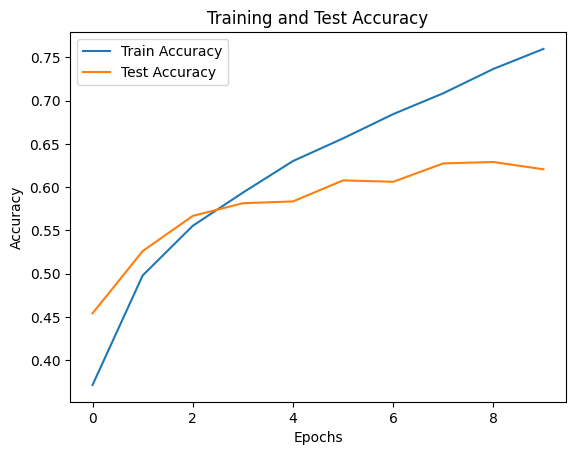

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.legend()
plt.title("Training and Test Accuracy")
plt.show()

In [ ]:
import random

In [ ]:
len(test_dataset)

10000

In [ ]:
test_dataset[0][0].unsqueeze(dim=0).shape

torch.Size([1, 3, 32, 32])

In [ ]:
test_dataset[0][0] / 2 + 0.5

tensor([[[0.6196, 0.6235, 0.6471,  ..., 0.5373, 0.4941, 0.4549],
         [0.5961, 0.5922, 0.6235,  ..., 0.5333, 0.4902, 0.4667],
         [0.5922, 0.5922, 0.6196,  ..., 0.5451, 0.5098, 0.4706],
         ...,
         [0.2667, 0.1647, 0.1216,  ..., 0.1490, 0.0510, 0.1569],
         [0.2392, 0.1922, 0.1373,  ..., 0.1020, 0.1137, 0.0784],
         [0.2118, 0.2196, 0.1765,  ..., 0.0941, 0.1333, 0.0824]],

        [[0.4392, 0.4353, 0.4549,  ..., 0.3725, 0.3569, 0.3333],
         [0.4392, 0.4314, 0.4471,  ..., 0.3725, 0.3569, 0.3451],
         [0.4314, 0.4275, 0.4353,  ..., 0.3843, 0.3725, 0.3490],
         ...,
         [0.4863, 0.3922, 0.3451,  ..., 0.3804, 0.2510, 0.3333],
         [0.4549, 0.4000, 0.3333,  ..., 0.3216, 0.3216, 0.2510],
         [0.4196, 0.4118, 0.3490,  ..., 0.3020, 0.3294, 0.2627]],

        [[0.1922, 0.1843, 0.2000,  ..., 0.1412, 0.1412, 0.1294],
         [0.2000, 0.1569, 0.1765,  ..., 0.1216, 0.1255, 0.1333],
         [0.1843, 0.1294, 0.1412,  ..., 0.1333, 0.1333, 0.

In [ ]:
import numpy as np

def predict_and_plot_grid(model,
                          dataset,
                          classes,
                          grid_size=3):
  model.eval()
  fig, axes = plt.subplots(grid_size, grid_size, figsize=(9,9))
  for i in range(grid_size):
    for j in range(grid_size):
      idx = random.randint(0, len(dataset) - 1)
      img, true_label = dataset[idx]
      input_tensor = img.unsqueeze(dim=0).to(device)
      with torch.inference_mode():
        output = model(input_tensor)
        _, predicted = torch.max(output.data, 1)
        img = img / 2 + 0.5
        npimg = img.cpu().numpy()
        axes[i, j].imshow(np.transpose(npimg, (1, 2, 0)))
        truth = classes[true_label] == classes[predicted.item()]
        if truth:
          color = "g"
        else:
          color = "r"

        axes[i, j].set_title(f"Truth: {classes[true_label]}\n, Predicted: {classes[predicted.item()]}", fontsize=10, c=color )
        axes[i, j].axis("off")
  plt.tight_layout()
  plt.show()

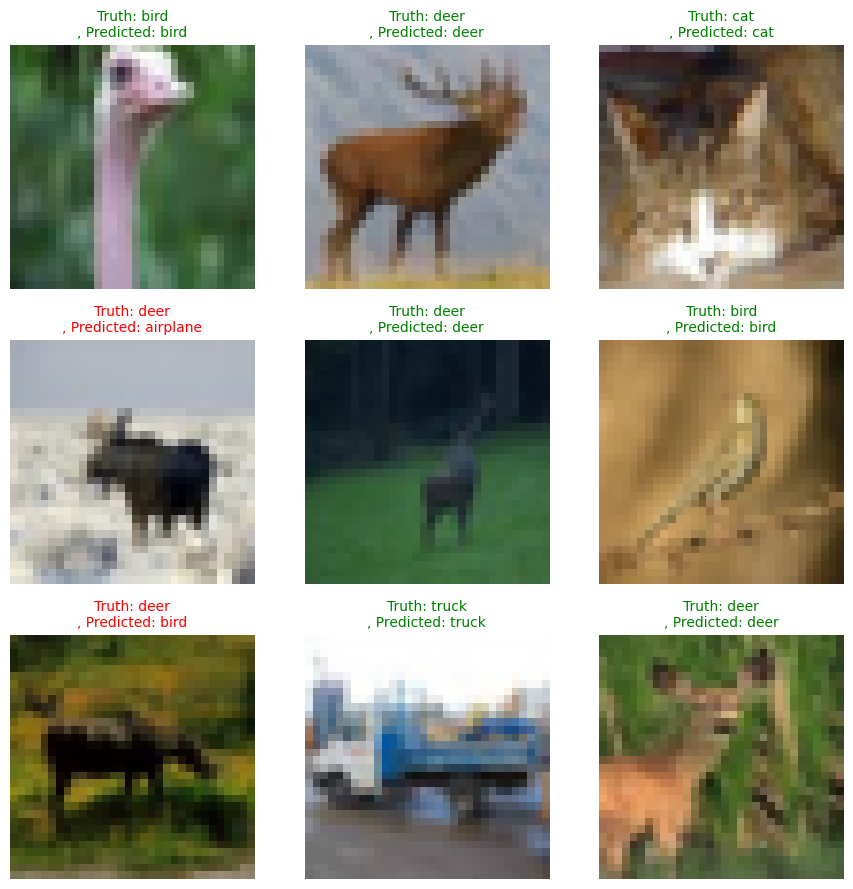

In [ ]:
predict_and_plot_grid(model, test_dataset, classes=train_dataset.classes, grid_size=3)

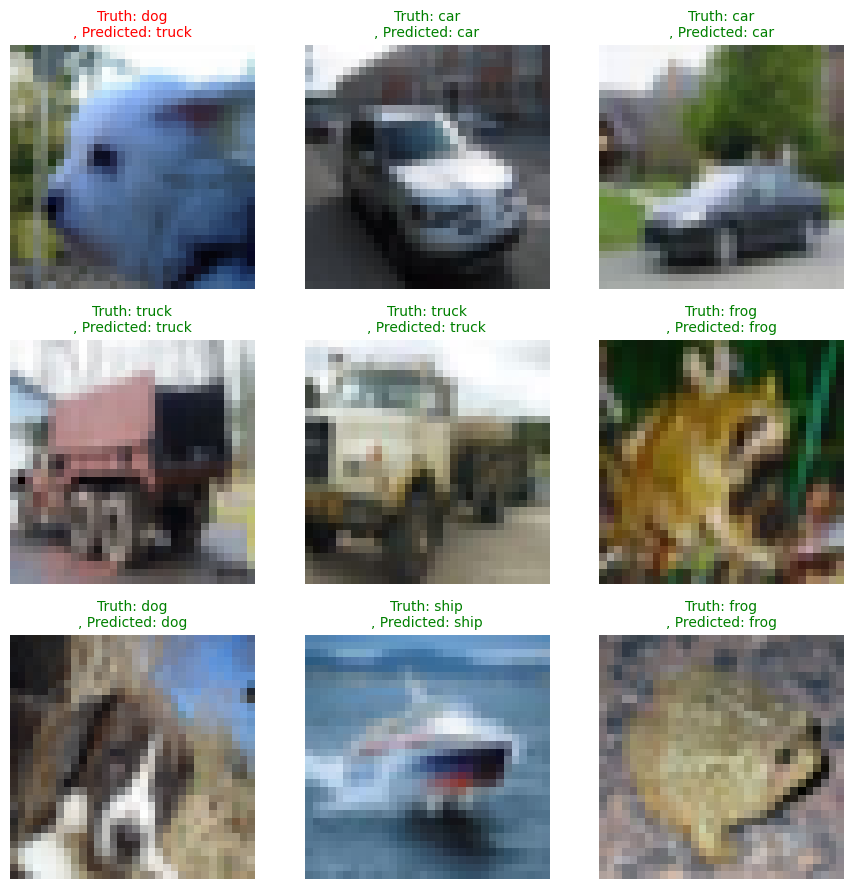

In [ ]:
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

predict_and_plot_grid(model, test_dataset, classes, grid_size=3)